In [81]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Importing data

In [82]:
df = pd.read_csv('Data/features_main.csv')
print(df.shape)
print(df['label'].value_counts())
print(df['split'].value_counts())
df.head()

(13489, 27)
label
0    8473
1    5016
Name: count, dtype: int64
split
train    9634
test     1928
val      1927
Name: count, dtype: int64


,uid,split,label,source,attack_type,obf_invisible,obf_homoglyphs,obf_fullwidth,obf_accents,obf_base64,...,lex_coercion,lex_harmful,delimiters,imperative_ratio,second_person_ratio,is_question,char_entropy,log_chars,upper_ratio,punct_ratio
0,safeguard:test:10,train,1,safeguard,instruction_override,0,0,0.0,0.000000,0,...,0,0,0,0.0,0.000000,0,3.928772,4.442651,0.013889,0.011905
1,safeguard:test:100,train,0,safeguard,none,0,0,0.0,0.000000,0,...,0,0,0,0.0,0.014286,0,4.456455,6.558198,0.041769,0.176136
2,safeguard:test:1001,train,0,safeguard,none,0,0,0.0,0.005249,0,...,0,0,0,0.0,0.000000,1,4.473714,5.945421,0.060201,0.039370
3,safeguard:test:1003,train,0,safeguard,none,0,0,0.0,0.000000,0,...,0,0,0,0.0,0.000000,0,4.193096,4.304065,0.018519,0.095890
4,safeguard:test:1005,train,0,safeguard,none,0,0,0.0,0.000000,0,...,0,0,0,0.0,0.142857,1,3.719852,3.465736,0.041667,0.032258


Data split

In [83]:
non_feature_cols = ['uid', 'split', 'label', 'source', 'attack_type']
feature_cols = [col for col in df.columns if col not in non_feature_cols]

train_df = df[df['split'] == 'train']
val_df   = df[df['split'] == 'val']
test_df  = df[df['split'] == 'test']

X_train, y_train = train_df[feature_cols], train_df['label']
X_val,   y_val   = val_df[feature_cols],   val_df['label']
X_test,  y_test  = test_df[feature_cols],  test_df['label']

print(feature_cols)
print(X_train.shape, X_val.shape, X_test.shape)

['obf_invisible', 'obf_homoglyphs', 'obf_fullwidth', 'obf_accents', 'obf_base64', 'evasion_gap', 'non_ascii_ratio', 'lex_override', 'lex_override_verb_only', 'lex_exfil', 'lex_roleplay', 'lex_prefix_refusal', 'lex_coercion', 'lex_harmful', 'delimiters', 'imperative_ratio', 'second_person_ratio', 'is_question', 'char_entropy', 'log_chars', 'upper_ratio', 'punct_ratio']
(9634, 22) (1927, 22) (1928, 22)


Training

In [84]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

Validation

In [85]:
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

print("--- Training Set ---")
print("Accuracy:", accuracy_score(y_train, train_preds))
print(classification_report(y_train, train_preds))

print("--- Validation Set ---")
print("Accuracy:", accuracy_score(y_val, val_preds))
print(classification_report(y_val, val_preds))

--- Training Set ---
Accuracy: 0.9402117500518995
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      6052
           1       0.97      0.86      0.91      3582

    accuracy                           0.94      9634
   macro avg       0.95      0.92      0.93      9634
weighted avg       0.94      0.94      0.94      9634

--- Validation Set ---
Accuracy: 0.9143746756616502
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      1210
           1       0.94      0.82      0.88       717

    accuracy                           0.91      1927
   macro avg       0.92      0.89      0.91      1927
weighted avg       0.92      0.91      0.91      1927



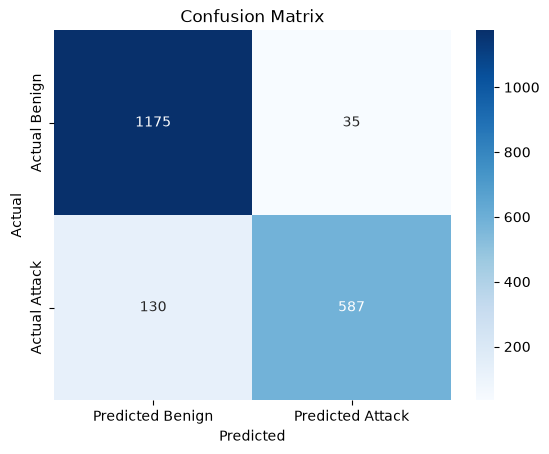

In [86]:
cm = confusion_matrix(y_val, val_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Benign', 'Predicted Attack'],
            yticklabels=['Actual Benign', 'Actual Attack'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

Testing

In [87]:
def evaluate_on_file(filepath, feature_cols, model):
    df_ext = pd.read_csv(filepath)
    X_ext = df_ext[feature_cols]
    y_ext = df_ext['label']
    
    preds = model.predict(X_ext)
    
    print(f"--- {filepath} ---")
    print("Accuracy:", accuracy_score(y_ext, preds))
    print(classification_report(y_ext, preds))
    print()
    
    return df_ext, preds


obf_df, obf_preds = evaluate_on_file('Data/features_test_obfuscated.csv', feature_cols, model)
temp_df, temp_preds = evaluate_on_file('Data/features_test_temporal.csv', feature_cols, model)
notinj_df, notinj_preds = evaluate_on_file('Data/features_test_notinject.csv', feature_cols, model)

--- Data/features_test_obfuscated.csv ---
Accuracy: 0.8583333333333333
              precision    recall  f1-score   support

           0       0.78      0.99      0.87       900
           1       0.98      0.73      0.84       900

    accuracy                           0.86      1800
   macro avg       0.88      0.86      0.86      1800
weighted avg       0.88      0.86      0.86      1800


--- Data/features_test_temporal.csv ---
Accuracy: 0.6453608247422681
              precision    recall  f1-score   support

           0       0.71      0.75      0.73       308
           1       0.52      0.46      0.49       177

    accuracy                           0.65       485
   macro avg       0.61      0.61      0.61       485
weighted avg       0.64      0.65      0.64       485


--- Data/features_test_notinject.csv ---
Accuracy: 0.8790560471976401
              precision    recall  f1-score   support

           0       1.00      0.88      0.94       339
           1       0.00  

c:\Users\seusa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\seusa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\seusa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [88]:
# Check source distribution in training data
print("Training set source breakdown:")
print(train_df['source'].value_counts())
print()

# Check source distribution in temporal test set  
print("Temporal test set source breakdown:")
print(pd.read_csv('Data/test_temporal.csv')['source'].value_counts())
print()

# Check: does lex_roleplay actually fire reliably for roleplay_jailbreak attacks?
print("Average lex_roleplay by attack_type (training data):")
print(train_df.groupby('attack_type')['lex_roleplay'].mean())

Training set source breakdown:
source
safeguard         7224
wild_regular       726
gandalf            713
wild_jailbreak     503
deepset            468
Name: count, dtype: int64

Temporal test set source breakdown:
source
wild_regular      308
wild_jailbreak    177
Name: count, dtype: int64

Average lex_roleplay by attack_type (training data):
attack_type
fake_completion_delimiter      0.276596
harmful_content_request        1.153846
instruction_override           0.062271
none                           0.154660
other_injection                0.000000
prefix_refusal_suppression     0.044280
prompt_leak_exfiltration       0.177320
roleplay_jailbreak             7.353116
social_engineering_coercion    0.042553
Name: lex_roleplay, dtype: float64
